In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

np.random.seed(42)
tf.random.set_seed(42)

# ---- function family: y = a * sqrt(b*x + c) + d ----
def sample_params(rng):
    a = rng.uniform(-2.0, 2.0)
    b = rng.uniform(0.1, 5.0)   # keep positive so domain is valid on x∈[0,1]
    c = rng.uniform(0.0, 1.0)   # ensures b*x + c >= 0
    d = rng.uniform(-1.0, 1.0)
    return np.array([a, b, c, d], dtype=np.float32)

def make_dataset(n_curves=1000, n_samples=50, noise_std=0.01, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    X = np.zeros((n_curves, n_samples*2), dtype=np.float32)  # flattened (x1,y1,x2,y2,...)
    Theta = np.zeros((n_curves, 4), dtype=np.float32)        # [a,b,c,d]
    for i in range(n_curves):
        theta = sample_params(rng)
        a,b,c,d = theta
        x = np.sort(rng.uniform(0.0, 1.0, size=n_samples)).astype(np.float32)
        y = a * np.sqrt(b * x + c) + d
        y_noisy = (y + rng.normal(0.0, noise_std, size=n_samples)).astype(np.float32)
        X[i] = np.column_stack([x, y_noisy]).reshape(-1)
        Theta[i] = theta
    return X, Theta

# generate data
N_TRAIN, N_TEST = 1000, 200
N_SAMPLES = 50
NOISE_STD = 0.01

X_train, T_train = make_dataset(N_TRAIN, N_SAMPLES, NOISE_STD)
X_test,  T_test  = make_dataset(N_TEST,  N_SAMPLES, NOISE_STD)

X_train.shape, T_train.shape, X_test.shape, T_test.shape


((1000, 100), (1000, 4), (200, 100), (200, 4))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │        51,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,452 (845.52 KB)

 Trainable params: 216,452 (845.52 KB)

 Non-trainable params: 0 (0.00 B)

Best val MSE: 0.41531258821487427
Best val MAE: 0.4222165048122406


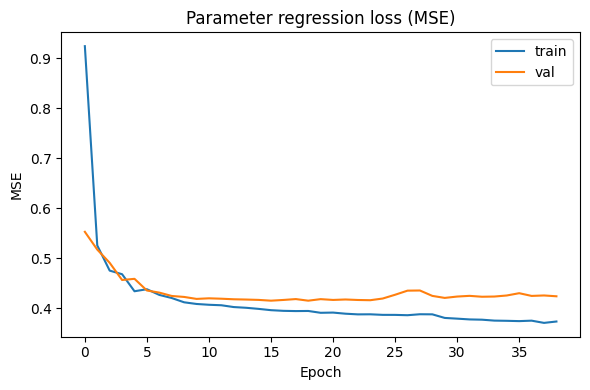

In [7]:
def build_model(input_dim):
    return models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(4,   activation='linear')  # predict [a,b,c,d]
    ])

model = build_model(X_train.shape[1])
model.summary()

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')]
)

es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
hist = model.fit(
    X_train, T_train,
    validation_split=0.15,
    epochs=300,
    batch_size=64,
    callbacks=[es],
    verbose=0
)

print("Best val MSE:", np.min(hist.history['val_loss']))
print("Best val MAE:", np.min(hist.history['val_mae']))

plt.figure(figsize=(6,4))
plt.plot(hist.history['loss'], label='train')
plt.plot(hist.history['val_loss'], label='val')
plt.title('Parameter regression loss (MSE)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.tight_layout(); plt.show()


In [5]:
pred_test = model.predict(X_test, verbose=0)
param_mae = np.mean(np.abs(pred_test - T_test), axis=0)
print("Per-parameter MAE  [a,     b,     c,     d]:")
print(param_mae)

overall_mae = np.mean(np.abs(pred_test - T_test))
print("Overall MAE on parameters:", overall_mae)


Per-parameter MAE  [a,     b,     c,     d]:
[0.24195038 0.9630519  0.22072773 0.21917604]
Overall MAE on parameters: 0.41122645


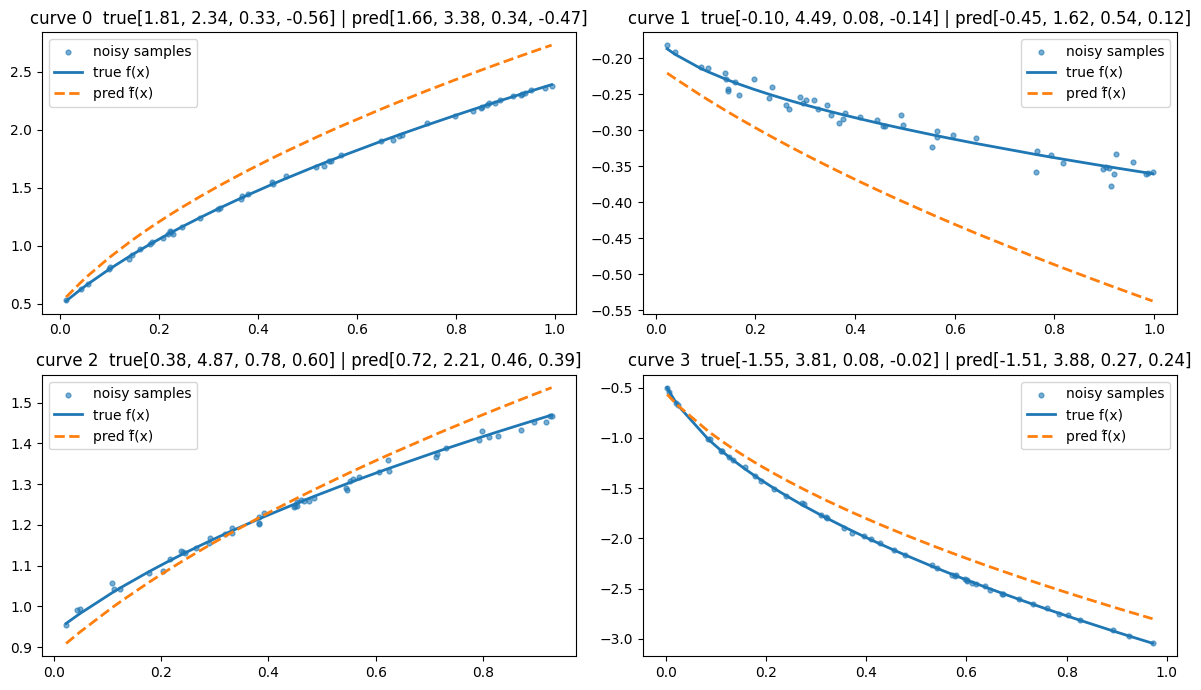

In [6]:
def sqrt_fn(x, theta):
    a,b,c,d = theta
    return a * np.sqrt(b * x + c) + d

def plot_recon(idx_list):
    cols = 2
    rows = int(np.ceil(len(idx_list)/cols))
    plt.figure(figsize=(6*cols, 3.5*rows))
    for k, idx in enumerate(idx_list, 1):
        theta_true = T_test[idx]
        theta_pred = pred_test[idx]
        # Rebuild the curve from the *same* x grid used for inputs (for a fair visual check)
        pair = X_test[idx].reshape(-1,2)
        x = pair[:,0]
        y_noisy = pair[:,1]
        y_true = sqrt_fn(x, theta_true)
        y_hat  = sqrt_fn(x, theta_pred)

        plt.subplot(rows, cols, k)
        plt.scatter(x, y_noisy, s=12, alpha=0.6, label='noisy samples')
        plt.plot(x, y_true,  lw=2, label='true f(x)')
        plt.plot(x, y_hat,   lw=2, ls='--', label='pred f̂(x)')
        tt = ", ".join([f"{v:.2f}" for v in theta_true])
        tp = ", ".join([f"{v:.2f}" for v in theta_pred])
        plt.title(f"curve {idx}  true[{tt}] | pred[{tp}]")
        plt.legend()
    plt.tight_layout()
    plt.show()

# Show a few examples
plot_recon([0,1,2,3])
